## Yoga and Mental Health

* An Exploratory Analysis
* Shaghayegh Malekshahi
* Data Exploration and Analysis

In [16]:
# STEP 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import statsmodels.api as sm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# STEP 2: Load Datasets

# Load all three datasets
google_trends = pd.read_csv("google_trends_yoga.csv")
happiness_data = pd.read_csv("happiness_data.csv")
survey_data = pd.read_csv("survey.csv")

In [3]:
# STEP 2A: Clean Google Trends Data  
# Rename the 4 existing columns
google_trends.columns = ['Yoga', 'MentalHealth', 'Stress', 'IsPartial']
google_trends.head()

,Yoga,MentalHealth,Stress,IsPartial
0,84,54,52,False
1,80,55,52,False
2,80,60,56,False
3,85,60,53,False
4,79,61,54,False


In [4]:
# STEP 2: Load and Clean Happiness Data
happiness_data = pd.read_csv("happiness_data.csv")

# Skip metadata rows and reset the index
happiness_data = happiness_data.iloc[2:].reset_index(drop=True)

# Rename columns
happiness_data.columns = ['Overall Rank', 'Country', 'Life Evaluation']

# Clean country names (remove footnotes)
import re
happiness_data['Country'] = happiness_data['Country'].apply(lambda x: re.sub(r'\[.*?\]', '', str(x)).strip())

# Standardize casing
happiness_data['Country'] = happiness_data['Country'].str.title()

# Convert to numeric
happiness_data['Life Evaluation'] = pd.to_numeric(happiness_data['Life Evaluation'], errors='coerce')
happiness_data['Overall Rank'] = pd.to_numeric(happiness_data['Overall Rank'], errors='coerce')
happiness_data.head()

,Overall Rank,Country,Life Evaluation
0,1,Lithuania,7.795
1,2,Israel,7.667
2,3,Iceland,7.658
3,4,Serbia,7.658
4,5,Denmark,7.598


In [7]:
# STEP 2C: Clean Survey Data 

# Rename columns for clarity
survey_data = survey_data.rename(columns={
    'self_employed': 'SelfEmployed',
    'family_history': 'FamilyHistory',
    'work_interfere': 'WorkInterfere',
    'no_employees': 'NumEmployees',
    'remote_work': 'RemoteWork',
    'tech_company': 'TechCompany',
    'wellness_program': 'WellnessProgram',
    'seek_help': 'SeekHelp',
    'mental_health_consequence': 'MentalHealthConsequence',
    'phys_health_consequence': 'PhysicalHealthConsequence',
    'mental_health_interview': 'MentalHealthInterview',
    'phys_health_interview': 'PhysicalHealthInterview',
    'mental_vs_physical': 'MentalVsPhysical',
    'obs_consequence': 'ObservedConsequence'
})

# Standardize 'Gender' values
survey_data['Gender'] = survey_data['Gender'].str.strip().str.lower()
survey_data['Gender'] = survey_data['Gender'].replace({
    'female': 'Female', 'f': 'Female', 'cis female': 'Female', 'female (cis)': 'Female',
    'male': 'Male', 'm': 'Male', 'cis male': 'Male', 'male-ish': 'Male',
    'trans-female': 'Transgender', 'trans male': 'Transgender',
    'non-binary': 'Non-binary', 'genderqueer': 'Non-binary',
    'agender': 'Non-binary', 'other': 'Other', 'fluid': 'Non-binary'
})

# Drop rows with 3 or more missing values
survey_data = survey_data.dropna(thresh=survey_data.shape[1] - 3)

# Fill missing values in SelfEmployed
survey_data['SelfEmployed'] = survey_data['SelfEmployed'].fillna('Unknown')
survey_data.head()

,Timestamp,Age,Gender,Country,state,SelfEmployed,FamilyHistory,treatment,WorkInterfere,NumEmployees,...,leave,MentalHealthConsequence,PhysicalHealthConsequence,coworkers,supervisor,MentalHealthInterview,PhysicalHealthInterview,MentalVsPhysical,ObservedConsequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,Unknown,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,Male,United States,IN,Unknown,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,Unknown,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,Unknown,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,Unknown,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [8]:
# STEP 3: Add Date Column to Google Trends Data

# Since no date column existed, we simulate one starting from Jan 1, 2023 (weekly data)
google_trends['Date'] = pd.date_range(start='2023-01-01', periods=len(google_trends), freq='W')
google_trends.head()

,Yoga,MentalHealth,Stress,IsPartial,Date
0,84,54,52,False,2023-01-01
1,80,55,52,False,2023-01-08
2,80,60,56,False,2023-01-15
3,85,60,53,False,2023-01-22
4,79,61,54,False,2023-01-29


In [9]:
print(google_trends.columns.tolist())

['Yoga', 'MentalHealth', 'Stress', 'IsPartial', 'Date']


In [10]:
# STEP 4: Summary Statistics of Key Variables

# Descriptive stats for univariate analysis
print("Summary Statistics:\n")
google_trends[['Yoga', 'MentalHealth', 'Stress']].describe()

Summary Statistics:



,Yoga,MentalHealth,Stress
count,53.000000,53.000000,53.000000
mean,80.283019,53.188679,49.207547
std,6.499637,7.248492,6.564352
min,68.000000,29.000000,33.000000
25%,76.000000,48.000000,43.000000
50%,80.000000,55.000000,50.000000
75%,84.000000,59.000000,55.000000
max,100.000000,65.000000,62.000000


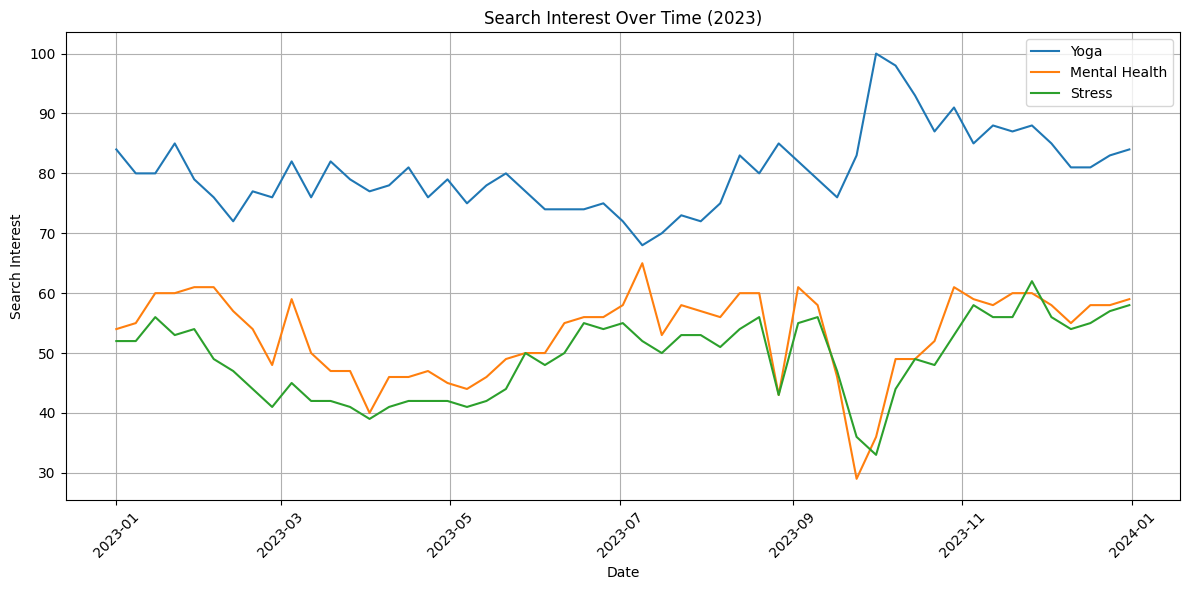

In [11]:
# STEP 5: Visualization of Key Variables

# Line plot showing trends over time
plt.figure(figsize=(12, 6))
plt.plot(google_trends['Date'], google_trends['Yoga'], label='Yoga')
plt.plot(google_trends['Date'], google_trends['MentalHealth'], label='Mental Health')
plt.plot(google_trends['Date'], google_trends['Stress'], label='Stress')
plt.title('Search Interest Over Time (2023)')
plt.xlabel('Date')
plt.ylabel('Search Interest')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

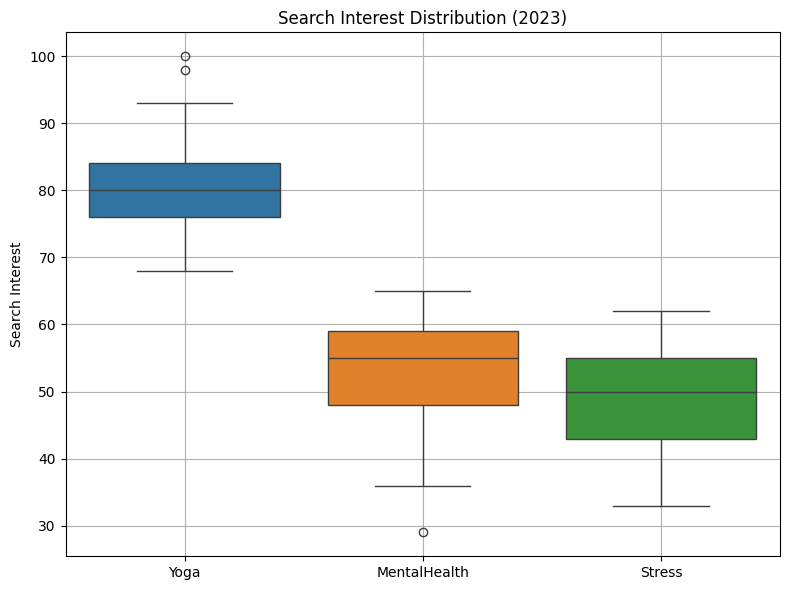

In [12]:
# Boxplot for distribution
plt.figure(figsize=(8, 6))
sns.boxplot(data=google_trends[['Yoga', 'MentalHealth', 'Stress']])
plt.title('Search Interest Distribution (2023)')
plt.ylabel('Search Interest')
plt.grid(True)
plt.tight_layout()
plt.show()


Covariance Matrix:

                   Yoga  MentalHealth     Stress
Yoga          42.245283     -6.669811  -1.021408
MentalHealth  -6.669811     52.540639  40.979318
Stress        -1.021408     40.979318  43.090711

Correlation Matrix:

                  Yoga  MentalHealth    Stress
Yoga          1.000000     -0.141572 -0.023940
MentalHealth -0.141572      1.000000  0.861242
Stress       -0.023940      0.861242  1.000000


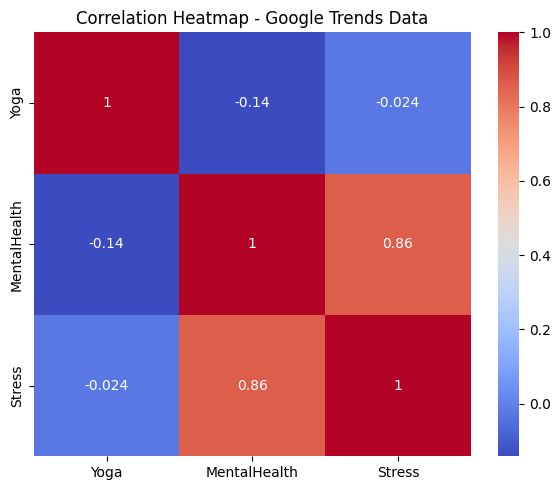

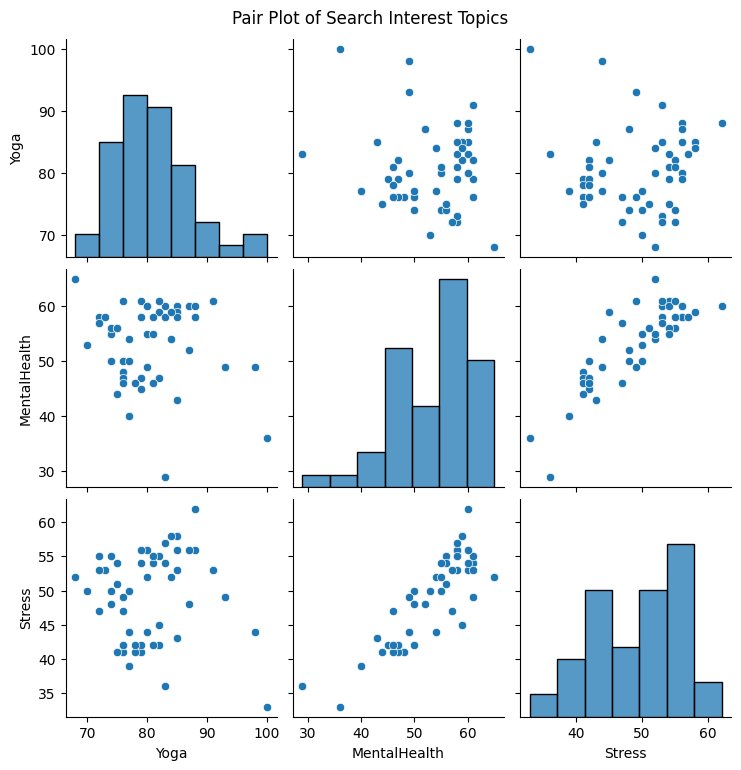

In [13]:
# STEP 6: Bivariate Analysis (Covariance & Correlation)

# Covariance matrix
print("\nCovariance Matrix:\n")
print(google_trends[['Yoga', 'MentalHealth', 'Stress']].cov())

# Pearson correlation matrix
print("\nCorrelation Matrix:\n")
print(google_trends[['Yoga', 'MentalHealth', 'Stress']].corr(method='pearson'))

# Heatmap of correlation
plt.figure(figsize=(6, 5))
sns.heatmap(google_trends[['Yoga', 'MentalHealth', 'Stress']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Google Trends Data')
plt.tight_layout()
plt.show()

# Pair plot
sns.pairplot(google_trends[['Yoga', 'MentalHealth', 'Stress']])
plt.suptitle('Pair Plot of Search Interest Topics', y=1.02)
plt.show()

In [14]:
# STEP 7: Hypothesis Testing (Paired t-test)

# H0: Yoga interest is <= mental health interest
# H1: Yoga interest is > mental health interest
# Hypothesis Test: Is Yoga > Mental Health in average weekly search interest?
t_stat, p_val = ttest_rel(google_trends['Yoga'], google_trends['MentalHealth'], alternative='greater')

print("\nPaired t-Test Result:")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")


Paired t-Test Result:
t-statistic = 18.9693, p-value = 2.5248e-25


                            OLS Regression Results                            
Dep. Variable:                   Yoga   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     11.75
Date:                Tue, 04 Nov 2025   Prob (F-statistic):            0.00121
Time:                        18:34:13   Log-Likelihood:                -168.41
No. Observations:                  53   AIC:                             340.8
Df Residuals:                      51   BIC:                             344.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.3650      1.649     45.712      0.0

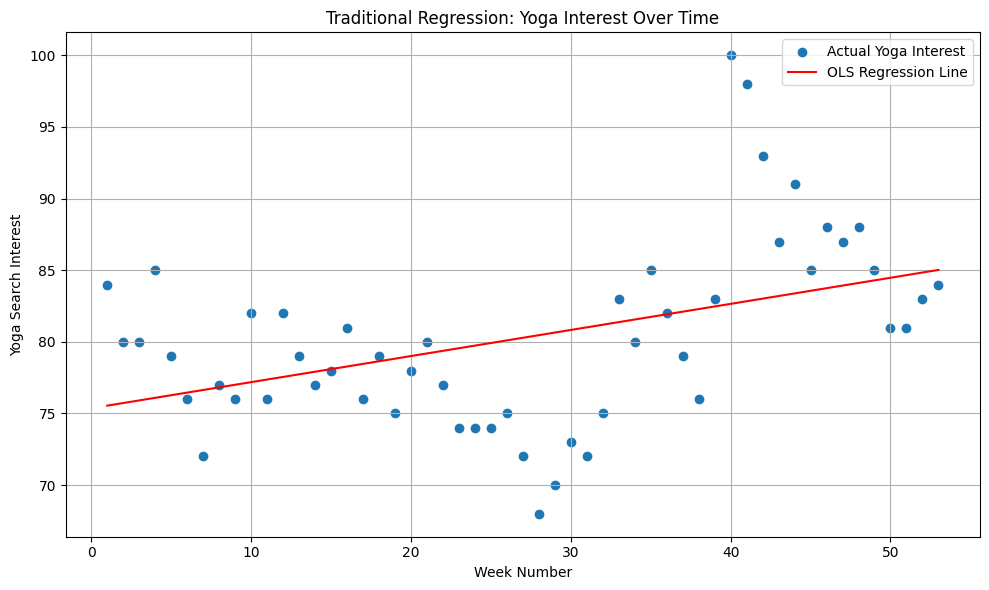

In [15]:
# STEP 8: Traditional Linear Regression using statsmodels

# Create week index variable
google_trends['week_num'] = range(1, len(google_trends) + 1)
X = sm.add_constant(google_trends[['week_num']])
y = google_trends['Yoga']
model = sm.OLS(y, X).fit()

# Print model summary
print(model.summary())


# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(google_trends['week_num'], y, label='Actual Yoga Interest')
plt.plot(google_trends['week_num'], model.predict(X), color='red', label='OLS Regression Line')
plt.xlabel('Week Number')
plt.ylabel('Yoga Search Interest')
plt.title('Traditional Regression: Yoga Interest Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Machine Learning Linear Regression:
Intercept = 75.37
Coefficient = 0.1821
MSE = 33.68
R² Score = 0.187


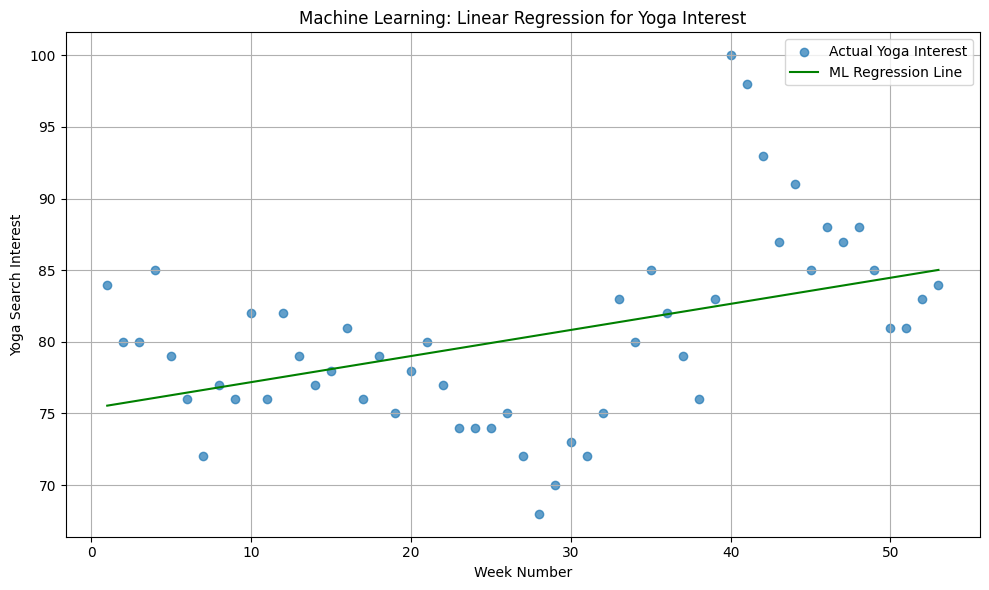

In [17]:
# STEP 9: Machine Learning Regression using scikit-learn

ml_model = LinearRegression()
X_ml = google_trends[['week_num']]
y_ml = google_trends['Yoga']
ml_model.fit(X_ml, y_ml)
y_pred = ml_model.predict(X_ml)

# Evaluate model
mse = mean_squared_error(y_ml, y_pred)
r2 = r2_score(y_ml, y_pred)
print("\nMachine Learning Linear Regression:")
print(f"Intercept = {ml_model.intercept_:.2f}")
print(f"Coefficient = {ml_model.coef_[0]:.4f}")
print(f"MSE = {mse:.2f}")
print(f"R² Score = {r2:.3f}")

# Plot ML regression
plt.figure(figsize=(10, 6))
plt.scatter(X_ml, y_ml, label='Actual Yoga Interest', alpha=0.7)
plt.plot(X_ml, y_pred, color='green', label='ML Regression Line')
plt.xlabel('Week Number')
plt.ylabel('Yoga Search Interest')
plt.title('Machine Learning: Linear Regression for Yoga Interest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Silhouette Score (k=3): 0.551


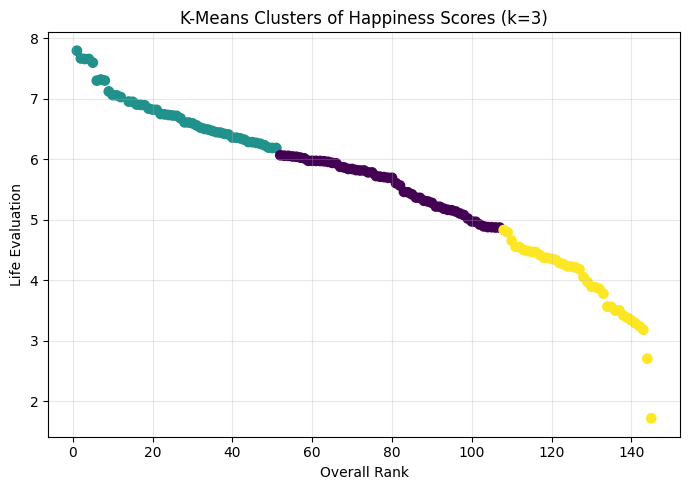

In [18]:
# STEP 10: K-Means Clustering on Happiness Data 
hdf = happiness_data.copy()
hdf = hdf.dropna(subset=['Life Evaluation'])  # ensure valid rows

# Standardize numeric columns for clustering
features = ['Overall Rank', 'Life Evaluation']
X = StandardScaler().fit_transform(hdf[features])

# Run K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
hdf['Cluster'] = labels

# Evaluate clustering
silhouette = silhouette_score(X, labels)
print(f"Silhouette Score (k=3): {silhouette:.3f}")

# Visualize clusters
plt.figure(figsize=(7,5))
plt.scatter(hdf['Overall Rank'], hdf['Life Evaluation'], c=hdf['Cluster'], s=45)
plt.xlabel('Overall Rank')
plt.ylabel('Life Evaluation')
plt.title('K-Means Clusters of Happiness Scores (k=3)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

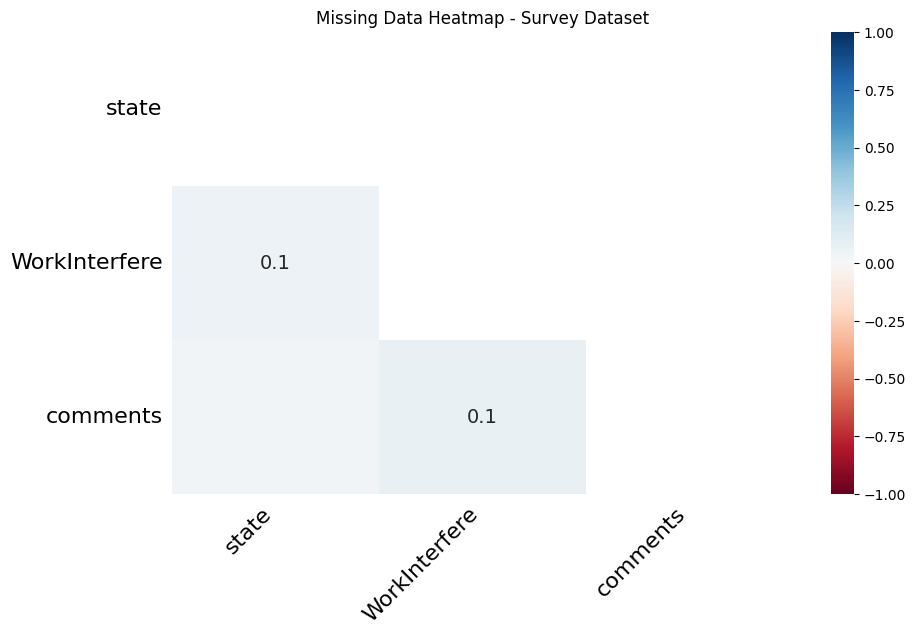

In [19]:
import missingno as msno

# Display missing value heatmap for the survey data
msno.heatmap(survey_data, figsize=(10, 6))
plt.title('Missing Data Heatmap - Survey Dataset')
plt.show()

### Logistic Regression Code (Predicting Mental Health Treatment)

####  Classification Model: Logistic Regression
#### Predict if a person has received treatment

In [20]:
# Import required libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
# Load the survey dataset (ensure the file is in your working directory)
survey_data = pd.read_csv("survey.csv")

In [22]:
#  Select relevant columns for classification
# Target: treatment | Features: age, gender, family history, work interference
survey_class = survey_data[['Age', 'Gender', 'family_history', 'work_interfere', 'treatment']].copy()

In [23]:
# Drop rows with missing values to simplify preprocessing
survey_class.dropna(inplace=True)

In [24]:
# Encode categorical variables using LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'family_history', 'work_interfere', 'treatment']:
    survey_class[col] = le.fit_transform(survey_class[col])

In [25]:
# Split data into features (X) and target (y)
X_class = survey_class.drop('treatment', axis=1)
y_class = survey_class['treatment']

In [26]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [27]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Train a logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [29]:
# Make predictions on the test set
y_pred = logreg.predict(X_test)

In [30]:
# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[ 37  28]
 [ 20 114]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.57      0.61        65
           1       0.80      0.85      0.83       134

    accuracy                           0.76       199
   macro avg       0.73      0.71      0.72       199
weighted avg       0.75      0.76      0.75       199



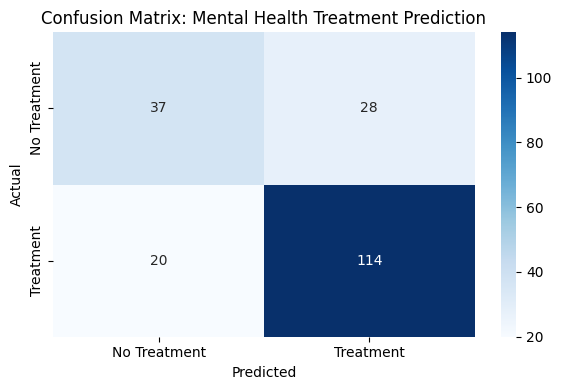

In [31]:
# Create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['No Treatment', 'Treatment']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Mental Health Treatment Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


ROC-AUC Score: 0.791


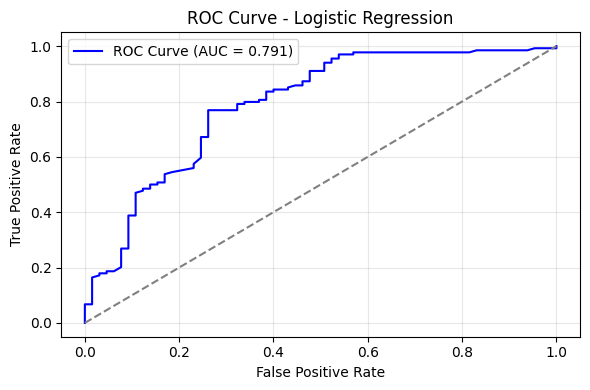

In [32]:
# ---- Additional Evaluation Metrics ----
from sklearn.metrics import roc_auc_score, roc_curve

# Probability scores for ROC-AUC
y_proba = logreg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("\nROC-AUC Score:", round(roc_auc, 3))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()